# Logistic Regression Project — Energy Generation Classification -1

**Goal:**  
Build and analyze a logistic regression model to classify whether an energy generation event represents high or low output using the U.S. Energy dataset (`energy.csv`).

---

## This notebook performs:

- **Data loading & inspection**
- **Target creation** (high vs low generation using median threshold)
- **Categorical encoding** (One-Hot Encoding)
- **Feature scaling** (Standardization)
- **Exploratory Data Analysis**  
  (distributions, correlations, bar charts)
- **Model building:**  
  - Custom Logistic Regression (from scratch, gradient descent)  
  - Scikit-learn LogisticRegression comparison  
- **Model evaluation**  
  - Accuracy  
  - Classification report  
  - Confusion matrix  
- **Interpretation of model coefficients**
- **Final conclusion and recommendations**

---

### **Note**

This notebook focuses on a binary classification task derived from continuous energy output.  
If the final objective is pure prediction (e.g., forecasting megawatt-hours), consider switching to regression models and adjusting preprocessing accordingly.


# Imports and Setup

In [38]:
# Step 0 – Imports and settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import OneHotEncoder

# Add src to path so we can import our custom package
import sys
sys.path.append("../../../src")

from rice_ml.processing.scaling import StandardScaler
from rice_ml.supervised_learning.logistic_regression import LogisticRegression
from sklearn.linear_model import LogisticRegression as SkLogisticRegression  # sklearn baseline

DATA_PATH = Path("../../../datasets/energy.csv")
print("Data path:", DATA_PATH.resolve())


Data path: /Users/alansalcedamonge/Desktop/577-project/INDE-577-Final-Project/datasets/energy.csv


# Load Data

In [39]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (496774, 7)

Columns: ['Unnamed: 0', 'YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Megawatthours)']


,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0


# Basic Info and Summary

In [40]:

print(df.info())
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496774 entries, 0 to 496773
Data columns (total 7 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  496774 non-null  int64  
 1   YEAR                        496774 non-null  int64  
 2   MONTH                       496774 non-null  int64  
 3   STATE                       496774 non-null  object 
 4   TYPE OF PRODUCER            496774 non-null  object 
 5   ENERGY SOURCE               496774 non-null  object 
 6   GENERATION (Megawatthours)  496774 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 26.5+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,496774.0,NaN,NaN,NaN,18143.269698,13387.090505,0.0,7762.0,15853.0,24178.0,65144.0
YEAR,496774.0,NaN,NaN,NaN,2011.649768,6.168041,2001.0,2006.0,2012.0,2017.0,2022.0
MONTH,496774.0,NaN,NaN,NaN,6.431452,3.458944,1.0,3.0,6.0,9.0,12.0
STATE,496774,52,US-TOTAL,18322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE OF PRODUCER,496774,6,Total Electric Power Industry,134452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENERGY SOURCE,496774,14,Total,73356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GENERATION (Megawatthours),496774.0,NaN,NaN,NaN,1393383.817259,10786845.79922,-997855.0,1643.0,23301.03,279204.2175,421796659.0


# Missing Values Overview

In [41]:

missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

# Visualize Missingness

In [42]:


if df.isna().any().any():
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isna(), cbar=False)
    plt.title("Missing value map (True = missing)")
    plt.show()
else:
    print("No missing values detected.")


No missing values detected.


# Create Binary Target

In [43]:
# Step 5 — Create binary target: HIGH vs LOW generation

GEN_COL = "GENERATION (Megawatthours)"

assert GEN_COL in df.columns, f"{GEN_COL} not found. Check column names."

threshold = df[GEN_COL].median()
print("Median generation threshold:", threshold)

df["target"] = (df[GEN_COL] > threshold).astype(int)
df["target"].value_counts(normalize=True)


Median generation threshold: 23301.03


target
1    0.5
0    0.5
Name: proportion, dtype: float64

# Explain Features and Target

### Variables overview

- **YEAR, MONTH** – Time information for each measurement.
- **STATE** – U.S. state code.
- **TYPE OF PRODUCER** – Category of producer (e.g., electric utility, IPP).
- **ENERGY SOURCE** – Primary energy source (coal, natural gas, wind, etc.).
- **GENERATION (Megawatthours)** – Continuous electricity generation quantity.
- **target** – Binary label:
  - `1` = High generation (above median)
  - `0` = Low generation (at or below median)

Goal: model the probability that a given record corresponds to **high** generation.


# EDA Distribution for Numeric Variables

Numeric columns: ['Unnamed: 0', 'YEAR', 'MONTH', 'GENERATION (Megawatthours)', 'target']


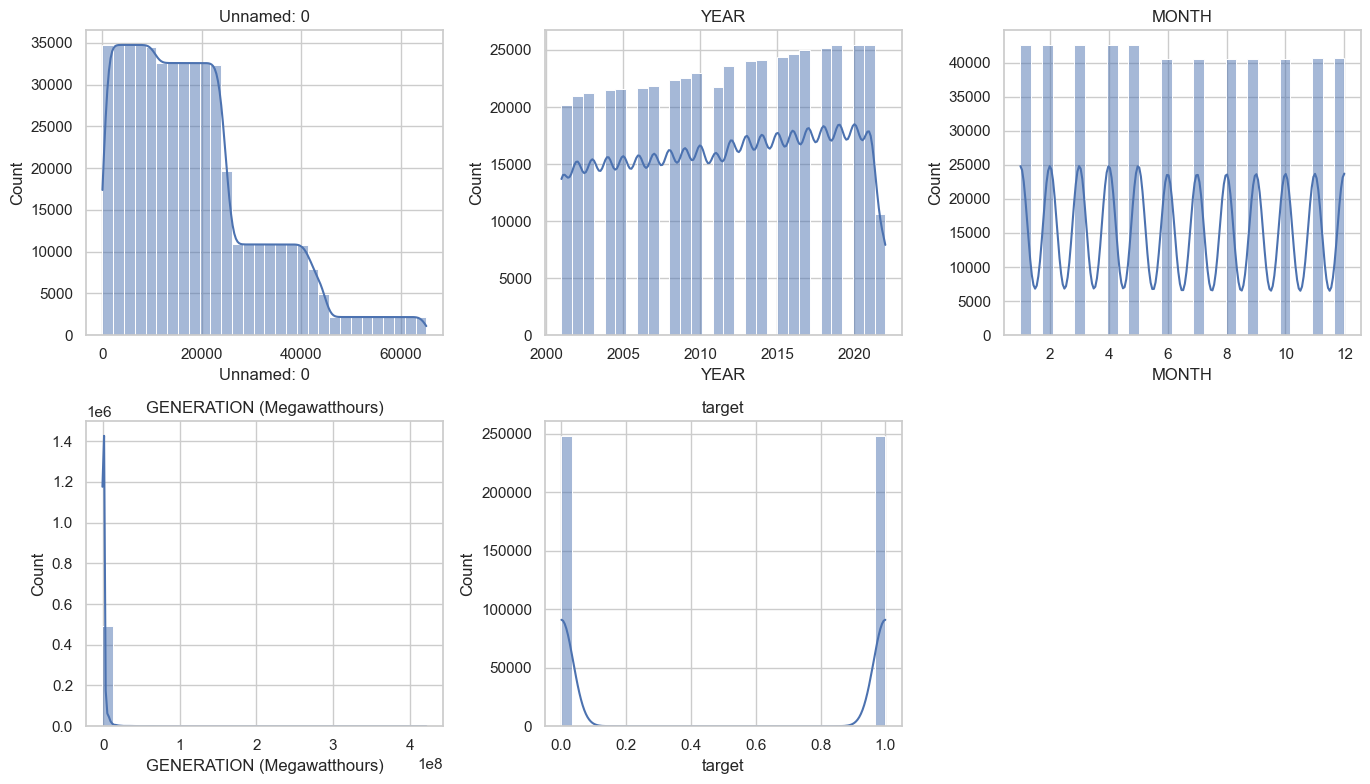

In [44]:
# Step 6 — EDA: distributions for numeric variables

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols):
    plt.subplot(int(np.ceil(len(num_cols) / 3)), 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


# EDA Categorical Distributions

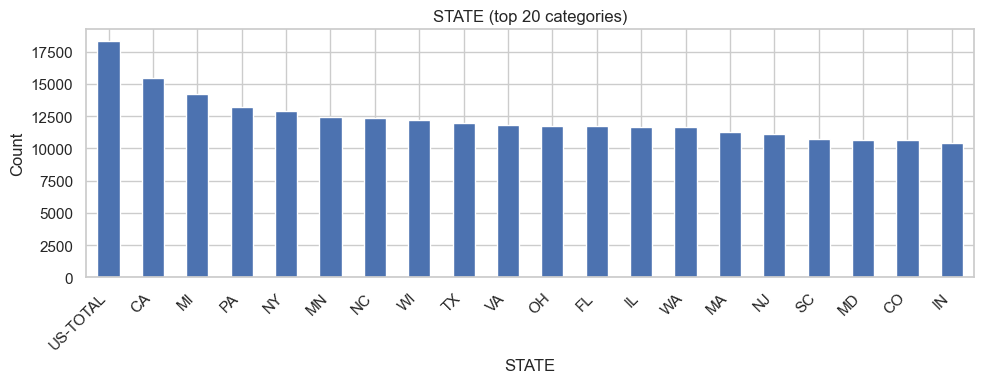

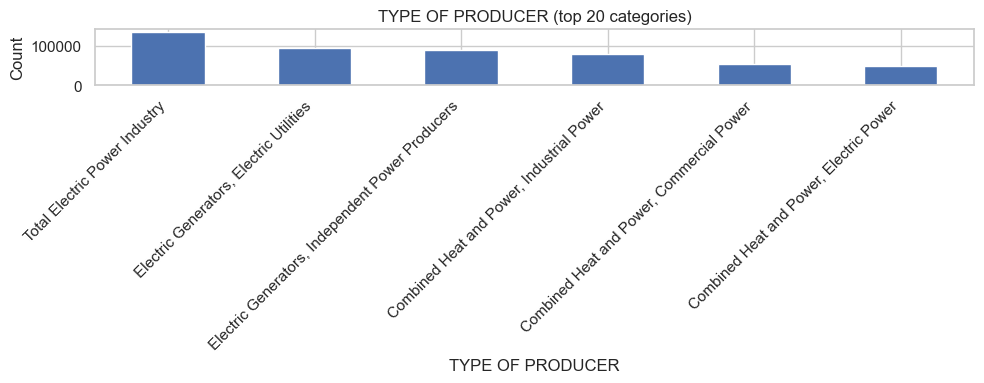

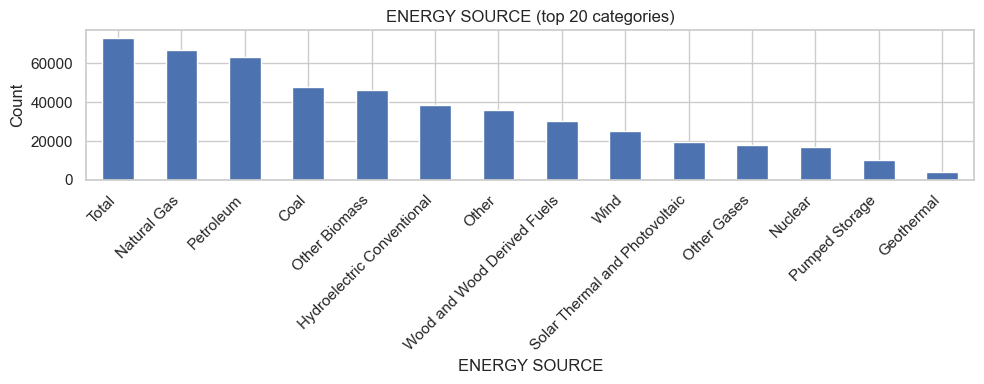

In [45]:
# Step 7 — EDA: categorical feature distributions

cat_cols = ["STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        df[col].value_counts().head(20).plot(kind="bar")
        plt.title(f"{col} (top 20 categories)")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


# Correlation (Only Numeric Values)

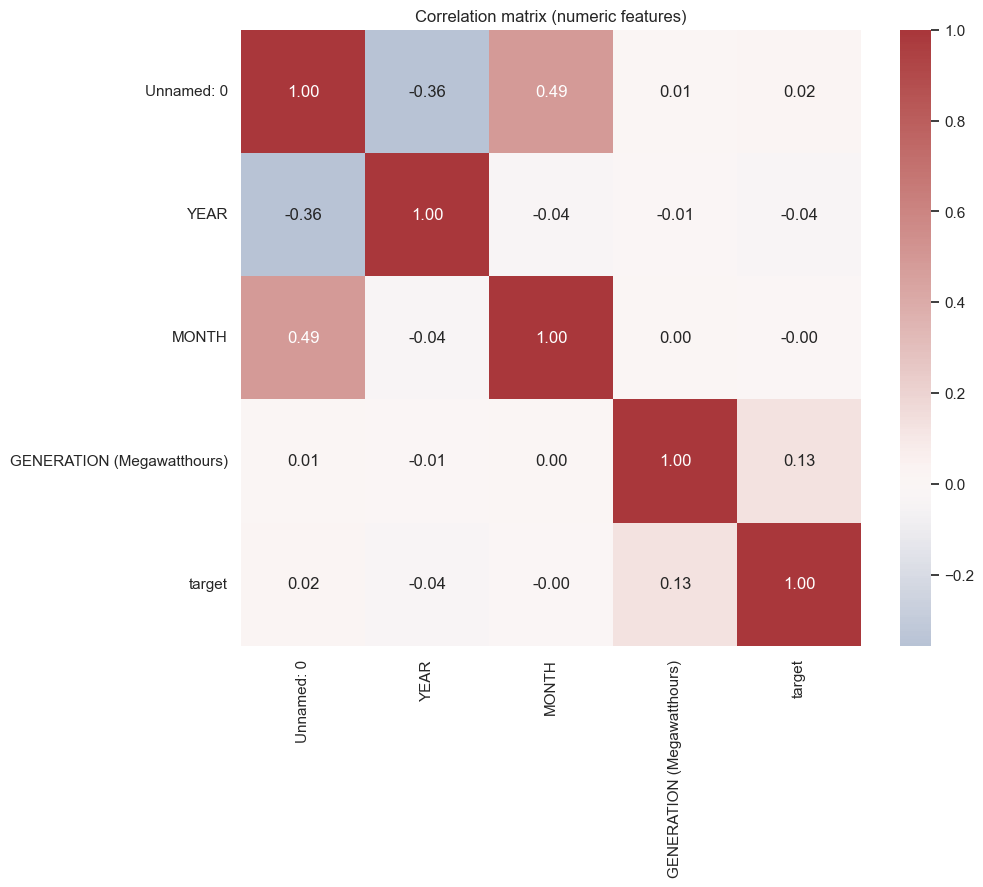

Correlations with target:
target                        1.000000
GENERATION (Megawatthours)    0.128966
Unnamed: 0                    0.017754
MONTH                        -0.001717
YEAR                         -0.036784
Name: target, dtype: float64


In [46]:
# Step 8 — Correlation matrix for numeric features

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

if "target" in corr.columns:
    print("Correlations with target:")
    print(corr["target"].sort_values(ascending=False))


# Prepare Features

In [47]:
# Step 9 — Prepare X and y (encoding + scaling)

feature_cols = ["YEAR", "MONTH", "STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]
X_raw = df[feature_cols].copy()
y = df["target"].copy()

# Separate numeric and categorical
num_features = ["YEAR", "MONTH"]
cat_features = ["STATE", "TYPE OF PRODUCER", "ENERGY SOURCE"]

X_num = X_raw[num_features].reset_index(drop=True)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = encoder.fit_transform(X_raw[cat_features])

cat_feature_names = encoder.get_feature_names_out(cat_features)

# Combine numeric + encoded categorical
X_all = np.hstack([X_num.values, X_cat])
all_feature_names = num_features + list(cat_feature_names)

X_all_df = pd.DataFrame(X_all, columns=all_feature_names)

print("Final feature matrix shape:", X_all_df.shape)
X_all_df.head()


Final feature matrix shape: (496774, 74)


,YEAR,MONTH,STATE_AK,STATE_AL,STATE_AR,STATE_AZ,STATE_CA,STATE_CO,STATE_CT,STATE_DC,...,ENERGY SOURCE_Nuclear,ENERGY SOURCE_Other,ENERGY SOURCE_Other Biomass,ENERGY SOURCE_Other Gases,ENERGY SOURCE_Petroleum,ENERGY SOURCE_Pumped Storage,ENERGY SOURCE_Solar Thermal and Photovoltaic,ENERGY SOURCE_Total,ENERGY SOURCE_Wind,ENERGY SOURCE_Wood and Wood Derived Fuels
0,2001.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2001.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2001.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2001.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2001.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Scale Features and Train/Test Splits

In [48]:
# Step 10 — Scaling and train/test split

scaler = StandardScaler()
X_scaled_np = scaler.fit_transform(X_all_df.values)
X_scaled = pd.DataFrame(X_scaled_np, columns=all_feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


Train shape: (397419, 74)
Test shape: (99355, 74)


(target
 1    0.500001
 0    0.499999
 Name: proportion, dtype: float64,
 target
 0    0.500005
 1    0.499995
 Name: proportion, dtype: float64)

# Fit custom Logistic Regression

In [49]:
# Step 11 — Fit custom Logistic Regression (from rice_ml)

log_reg = LogisticRegression(
    lr=0.05,
    num_iter=8000,
    fit_intercept=True,
    verbose=False
)

log_reg.fit(X_train.values, y_train.values)

# Basic check
print("Model parameters shape:", log_reg.theta.shape)


Model parameters shape: (75,)


# Evaluate Custom logistic Regression

Custom Logistic Regression Accuracy: 0.7948

Classification report (custom model):
              precision    recall  f1-score   support

           0     0.8011    0.7844    0.7926     49678
           1     0.7888    0.8052    0.7969     49677

    accuracy                         0.7948     99355
   macro avg     0.7949    0.7948    0.7948     99355
weighted avg     0.7949    0.7948    0.7948     99355



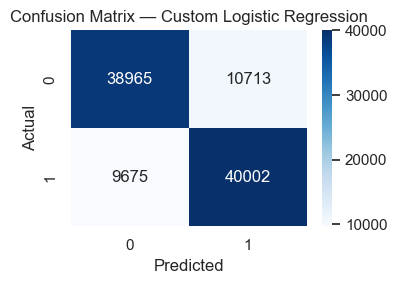

In [50]:
# Step 12 — Evaluation: accuracy, classification report, confusion matrix

y_pred_custom = log_reg.predict(X_test.values)
y_proba_custom = log_reg.predict_proba(X_test.values)

acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Custom Logistic Regression Accuracy: {acc_custom:.4f}\n")

print("Classification report (custom model):")
print(classification_report(y_test, y_pred_custom, digits=4))

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Custom Logistic Regression")
plt.tight_layout()
plt.show()


# ROC Curve and AUC

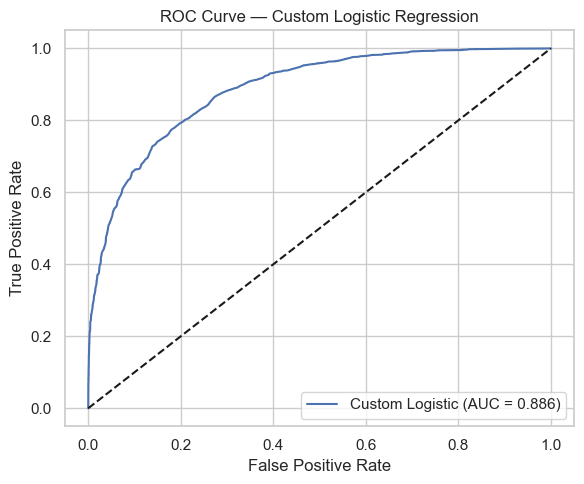

Custom Logistic Regression AUC: 0.8860552596238143


In [51]:
# Step 13 — ROC curve and AUC for custom model

fpr, tpr, thresholds = roc_curve(y_test, y_proba_custom)
roc_auc_custom = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Custom Logistic (AUC = {roc_auc_custom:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("Custom Logistic Regression AUC:", roc_auc_custom)


# Compare with scikit-learn LogisticRegression

In [52]:
# Step 14 — Comparison with scikit-learn LogisticRegression

sk_model = SkLogisticRegression(max_iter=1000)
sk_model.fit(X_train, y_train)

y_pred_sk = sk_model.predict(X_test)
y_proba_sk = sk_model.predict_proba(X_test)[:, 1]

acc_sk = accuracy_score(y_test, y_pred_sk)
print(f"Sklearn LogisticRegression Accuracy: {acc_sk:.4f}\n")

print("Classification report (sklearn):")
print(classification_report(y_test, y_pred_sk, digits=4))

fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba_sk)
roc_auc_sk = auc(fpr_sk, tpr_sk)
print("Sklearn LogisticRegression AUC:", roc_auc_sk)


Sklearn LogisticRegression Accuracy: 0.7948

Classification report (sklearn):
              precision    recall  f1-score   support

           0     0.8011    0.7843    0.7926     49678
           1     0.7887    0.8053    0.7969     49677

    accuracy                         0.7948     99355
   macro avg     0.7949    0.7948    0.7948     99355
weighted avg     0.7949    0.7948    0.7948     99355

Sklearn LogisticRegression AUC: 0.8860544500135232


# Plot ROC Curves Together

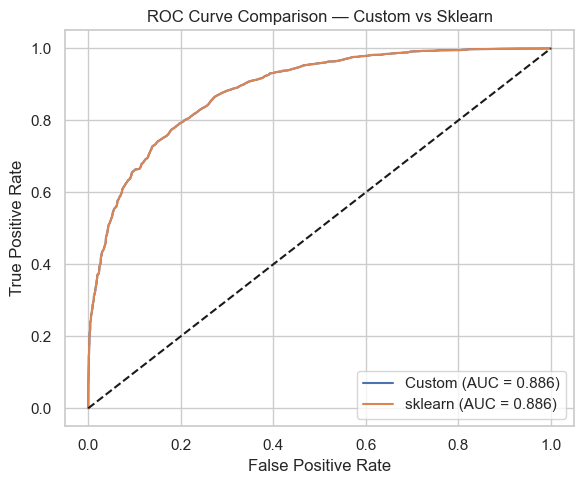

In [53]:
# Step 15 — ROC comparison: custom vs sklearn

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Custom (AUC = {roc_auc_custom:.3f})")
plt.plot(fpr_sk, tpr_sk, label=f"sklearn (AUC = {roc_auc_sk:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Custom vs Sklearn")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Cross validation

In [54]:
# Step 16 — 5-fold cross-validation using custom Logistic Regression

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = []

for train_idx, val_idx in kf.split(X_scaled, y):
    X_tr, X_val = X_scaled.iloc[train_idx].values, X_scaled.iloc[val_idx].values
    y_tr, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values
    
    model_cv = LogisticRegression(lr=0.05, num_iter=8000, fit_intercept=True, verbose=False)
    model_cv.fit(X_tr, y_tr)
    preds_val = model_cv.predict(X_val)
    
    cv_acc.append(accuracy_score(y_val, preds_val))

print("CV Accuracy scores:", np.round(cv_acc, 4))
print("Mean CV Accuracy:", np.round(np.mean(cv_acc), 4))


CV Accuracy scores: [0.7929 0.7951 0.7968 0.7911 0.7963]
Mean CV Accuracy: 0.7944


# Interpretation

### Model Performance & Interpretation

- **Overall accuracy**: (insert value) — indicates how often the model correctly classifies
  high vs low generation.
- **AUC**: (insert custom & sklearn AUC) — summarizes the trade-off between
  true positive and false positive rates.
- **Class balance**: Use the value_counts above to comment on whether the dataset is
  imbalanced and how that might affect interpretation.

**Feature interpretation (logistic coefficients):**

Because features are standardized, the sign of each coefficient indicates:

- Positive coefficient → increases the log-odds (and probability) of *high* generation.
- Negative coefficient → associated with *low* generation.

You can inspect `sk_model.coef_` together with `all_feature_names` to identify which states,
producers, or energy sources are most strongly associated with high generation levels.
